# Same-block sniper, reverse-engineered

**Wallet** `5brv79eFZ2rGprXNvqgVJBkBptkkw8GJX1XydJyZLyAr`  
Kaggle: [Solana Sniper Bot Reverse-Engineering](https://www.kaggle.com/competitions/solana-sniper-bot-reverse-engineering)

This notebook is the **readable paper**. Full pipeline code lives in the GitHub repo (`scripts/`, `src/`).  
It runs without the 30+ GB raw dump: figures and numbers are already computed under `t_decision` = deploy `blockTime` (no future prices as features).


## What the bot actually does (one screen)

He does **not** predict whether a token will moon. He:

1. Buys in the **same Solana block** as the create (~80% of the time, ~400 ms).
2. Mostly follows **deployers he already bought** (hot).
3. When the deployer is new (cold), **skips token factories** (3+ launches in an hour, last launch ~2 minutes ago, create size in cents) and prefers a quiet wallet that this time puts ~1 SOL into the create.

Then he sells in about **1 second**. After gas + tip + DEX he is still green: **+8,894 SOL** net (hit rate 56%, max drawdown ~−47 SOL).


In [1]:
from pathlib import Path
from IPython.display import Image, Markdown, display

CANDIDATES = [
    Path("assets"),                                  # next to this notebook (GitHub / local)
    Path("/kaggle/input/solana-sniper-assets"),      # if you attach a tiny Kaggle Dataset
    Path("../data/metadata/kaggle_writeup"),         # repo layout
]

def find_assets() -> Path:
    for p in CANDIDATES:
        if (p / "01_same_block.png").exists():
            return p
    raise FileNotFoundError("Figure assets not found. Keep notebooks/assets/ next to this file.")

ASSETS = find_assets()

def show(name: str, caption: str) -> None:
    display(Image(filename=str(ASSETS / name)))
    display(Markdown(f"*{caption}*"))

print("assets:", ASSETS.resolve())


assets: /home/eduardo/Programming/KAGGLE/solana_sniper/notebooks/assets


## Part 1 — Behavior (rubric ~20 pts)


**Latency.** 15,927 snipes. Median wait **0 s**. 79.6% same slot, 18.7% next slot, 1.7% later.  
The sniper is **never** the create signer. Same-slot buy sits ~118 tx indices *after* the create: he saw it in the mempool/bundle, not by signing the mint.

**Size / hold.** Median entry **1.98 SOL**. Median time to first sell **1 s**. This is a hunter, not an investor.


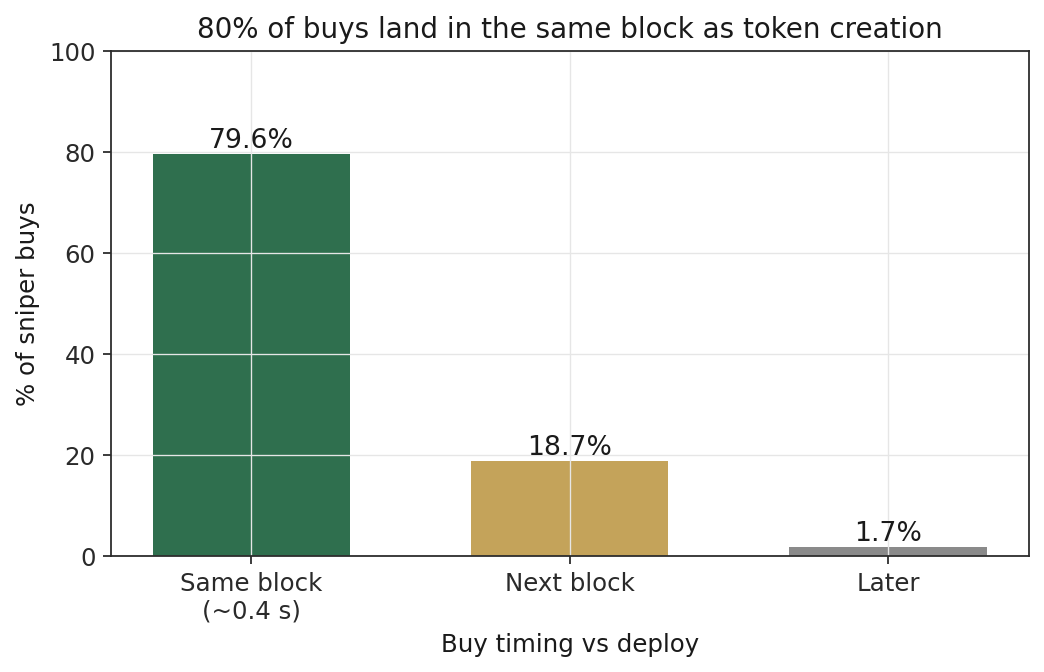

*Figure 1 — 79.6% of first buys land in the same ~400 ms block as the token create.*

In [2]:
show("01_same_block.png",
     "Figure 1 — 79.6% of first buys land in the same ~400 ms block as the token create.")


**P&L (SOL/WSOL quotes only, after gas + tip + DEX).**  
15,708 closed books: gross +17,629 → fees −8,735 → **net +8,894 SOL**. Hit rate 55.6% (mean win +1.40 / mean loss −0.47).  
Without fees the hit rate *looks* like 78%. Fees are half the story. Max drawdown ≈ **−47 SOL** on that equity path.

Hot books +5,794 SOL; cold books +2,938 SOL (rarer, slightly higher mean).


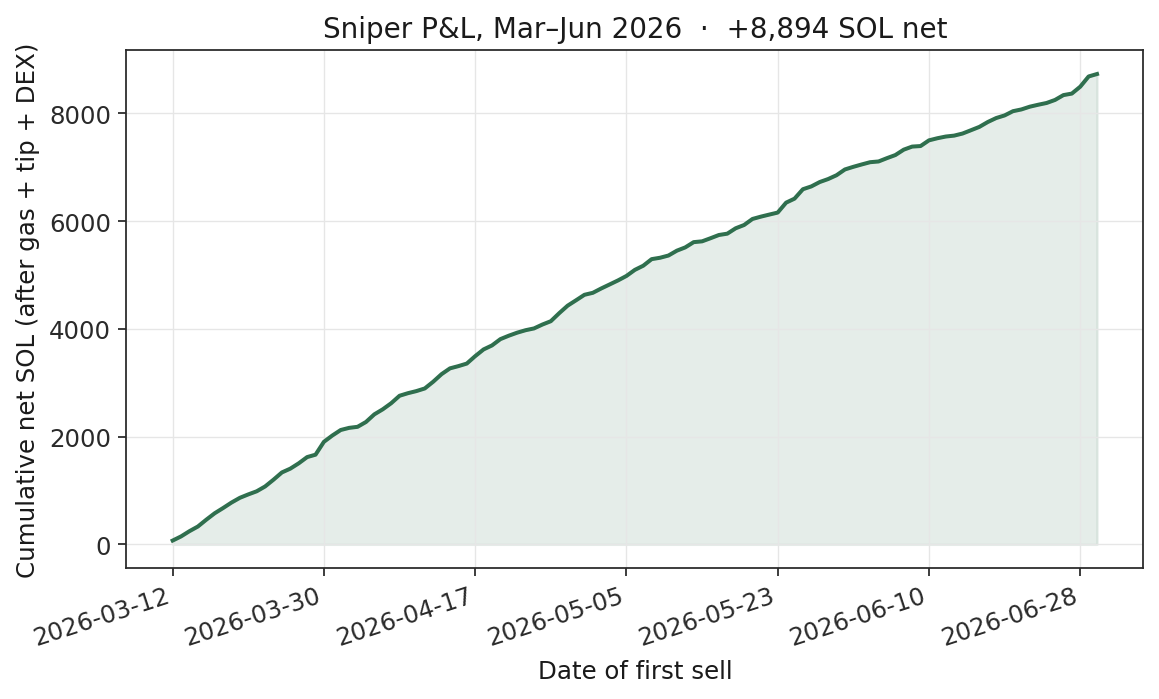

*Figure 2 — Cumulative net SOL, Mar–Jun 2026. Almost monotonic; the book does not need a miracle month.*

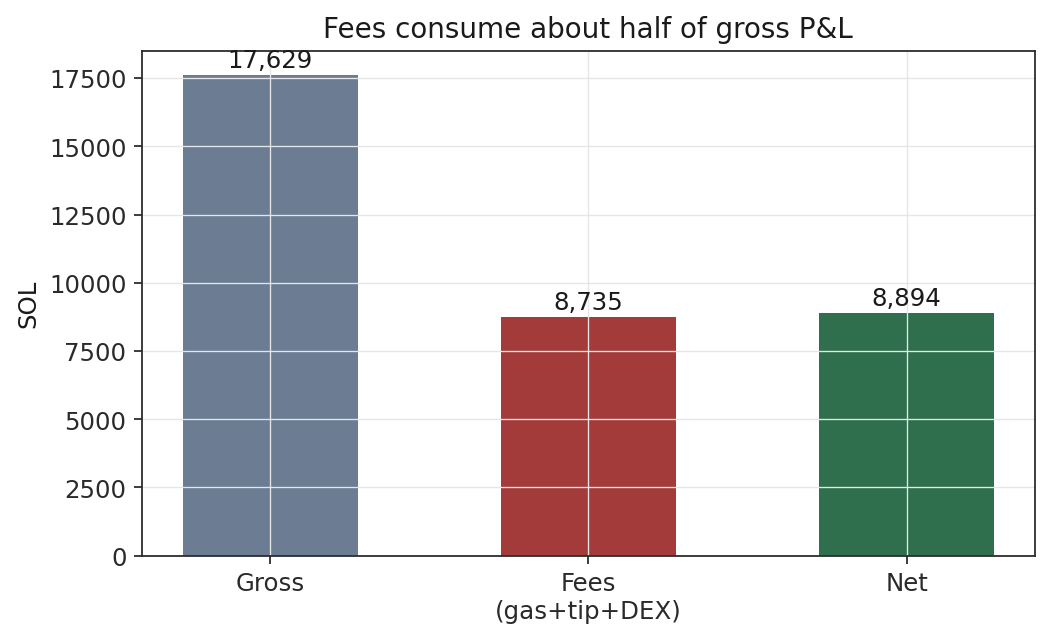

*Figure 3 — Fees consume about half of gross. Always report net.*

In [3]:
show("05_equity.png",
     "Figure 2 — Cumulative net SOL, Mar–Jun 2026. Almost monotonic; the book does not need a miracle month.")
show("06_fees.png",
     "Figure 3 — Fees consume about half of gross. Always report net.")


## Part 2 — Features and rules at `t_decision` (rubric ~20 pts)


Every feature is known at or **before** deploy `blockTime`. No mcap, no post-deploy trades, no “it went up later”.

**Rule A — known deployer (hot).**  
`prior_bought_same_signer > 0` *before* this deploy. June sample buy rate **38.8%** vs **4.8%** cold. That flag alone: ROC **0.77**.


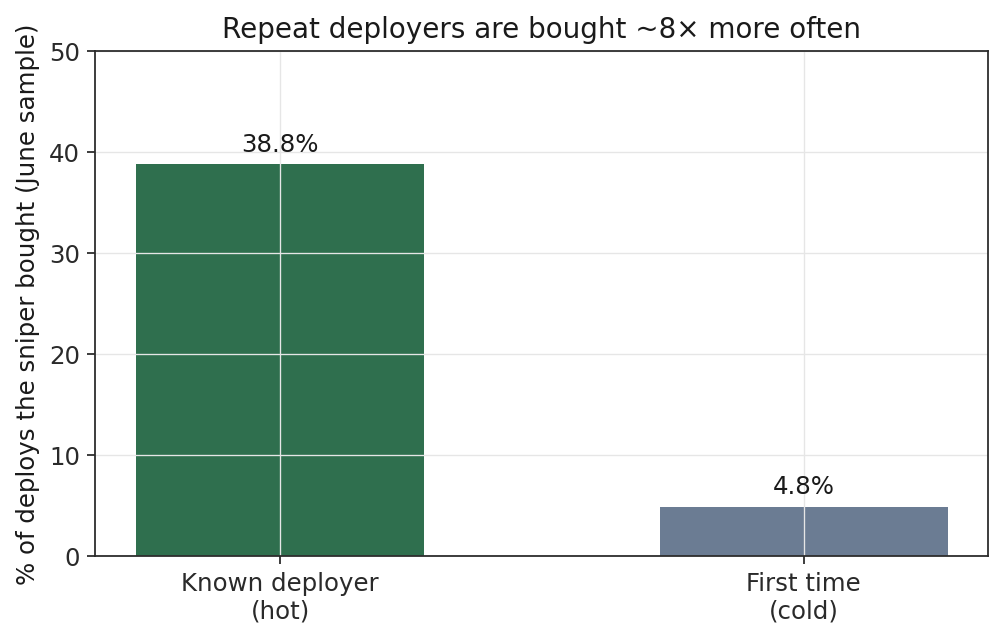

*Figure 4 — Repeat deployers are bought ~8× more often (June holdout sample).*

In [4]:
show("02_hot_vs_cold.png",
     "Figure 4 — Repeat deployers are bought ~8× more often (June holdout sample).")


**Rule B — anti-factory (cold only).**  
Not a secret price. A spray filter:

| At `t_decision` | He buys | He skips |
|---|---|---|
| 3+ launches in last hour | 0.75% | 7.5% if no burst |
| Hours since last launch (median) | ~26 h | ~2.5 min |
| SOL spent in the create (median) | ~1.03 | ~0.16 |

What **failed** (tested, discarded): empty from/to, shared tx with hot wallets, “rare token” overlap (dies in June), astra/rapid tips on cold (30% vs 31%), extra think-time on cold (same-slot rate is not slower).


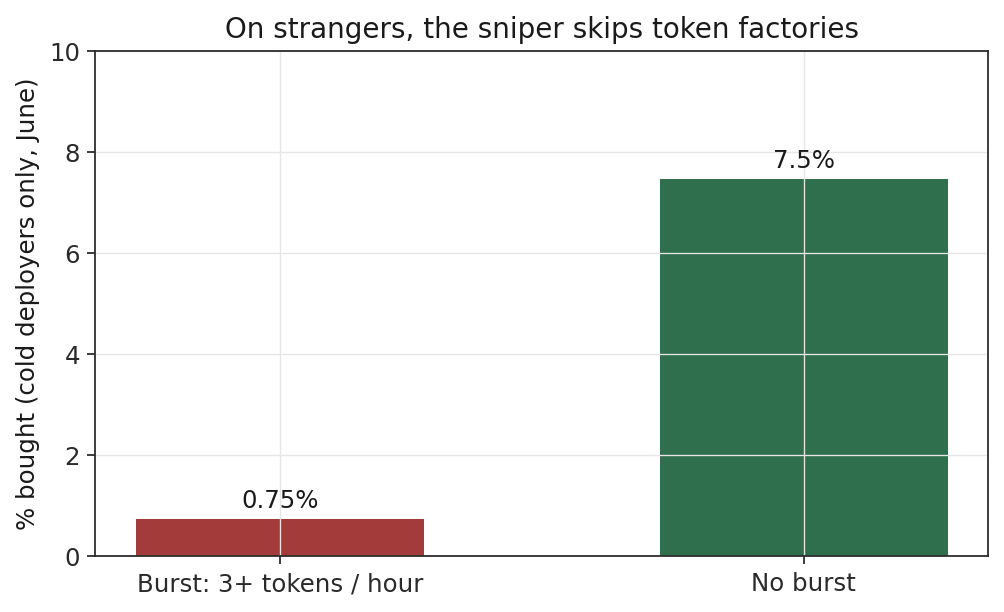

*Figure 5 — On strangers, a 3+/hour launch burst almost kills the buy rate.*

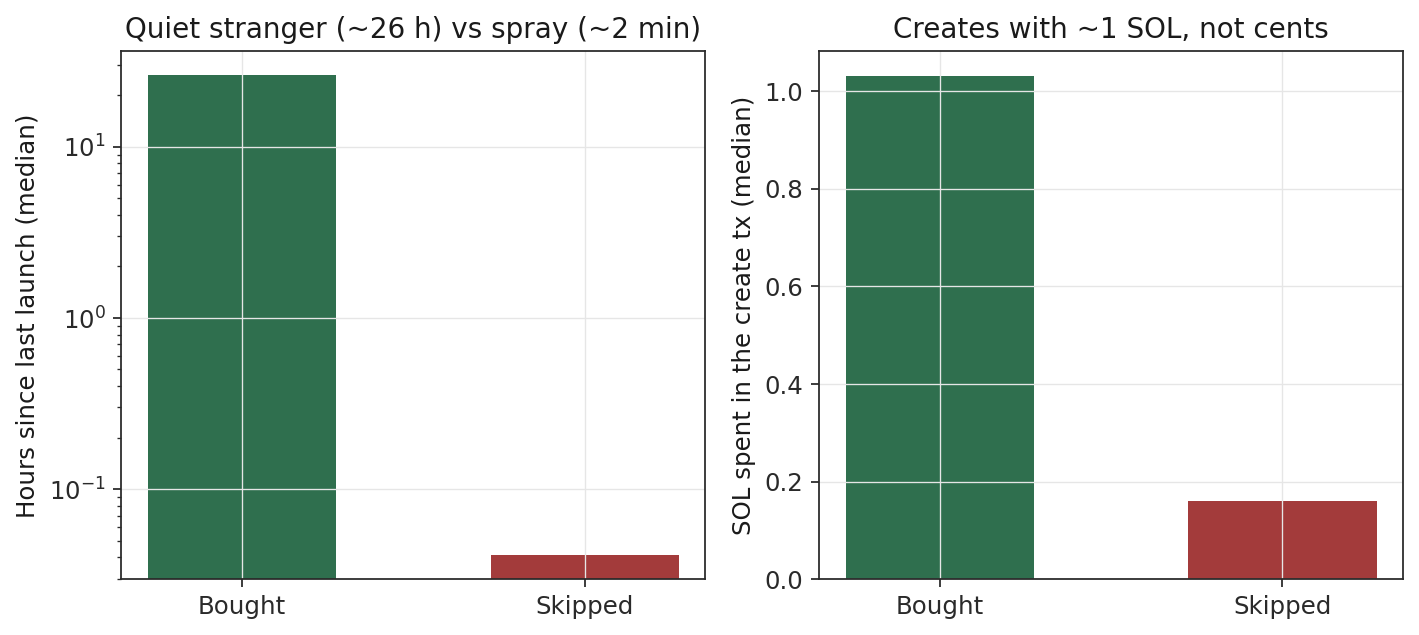

*Figure 6 — Quiet for ~26 h and ~1 SOL in the create vs spray + cents.*

In [5]:
show("03_anti_factory.png",
     "Figure 5 — On strangers, a 3+/hour launch burst almost kills the buy rate.")
show("11_quiet_and_sol.png",
     "Figure 6 — Quiet for ~26 h and ~1 SOL in the create vs spray + cents.")


## Part 2 — Classifier (rubric ~15 pts)


**Split (time, not random):** train < 2026-05-29 ≤ valid < 2026-06-12 ≤ **test**.  
Threshold = max F1 on **valid only** (0.23). Test is not used to pick it.

**Model:** `HistGradientBoostingClassifier` (depth 6, 350 iter). **No 15× class weight** — that version inflated scores and *lowered* PR/F1.  
Universe: all 15,927 positives + ~197k sampled negatives (not the full ~5M).

| Split | n | ROC | PR-AUC | P | R | F1 | P@100 |
|---|---|---|---|---|---|---|---|
| Valid | 17,286 | 0.94 | 0.71 | 0.62 | 0.78 | 0.69 | 0.93 |
| **Test** | 22,132 | **0.95** | **0.70** | **0.56** | **0.81** | **0.66** | **0.93** |

Ablation, test ROC: known-flag 0.77 → tx shape 0.88 → known+tx 0.92 → all **0.95**.  
One-line rule “if hot, buy” has F1 **0.49**. The model reaches **0.66**.

**Honest bound.** A public kernel on this competition reports June AP **0.22** on the **full** ~852k deploys. Our 0.70 is the same mechanism on an easier sample. We do not claim 0.70 on the raw universe.


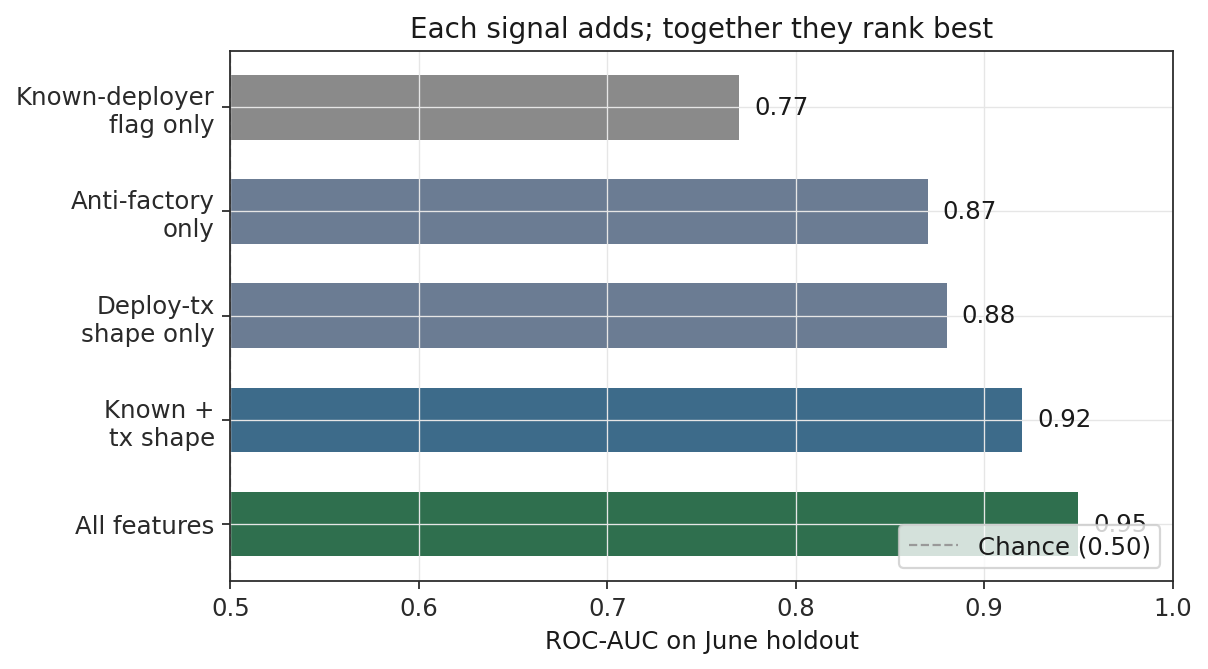

*Figure 7 — Each block of features adds ranking power; all three together win.*

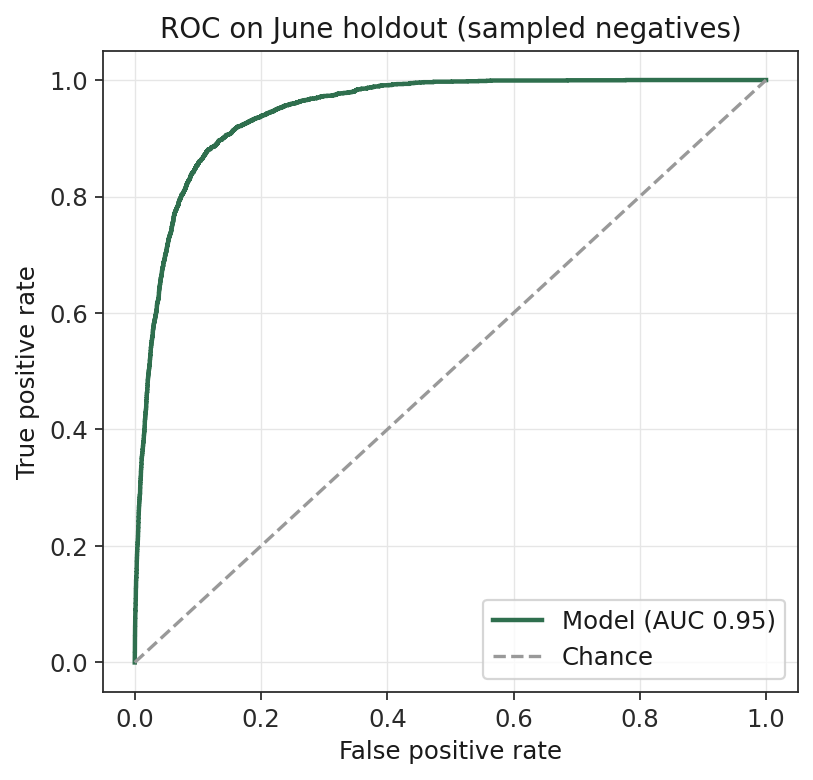

*Figure 8 — ROC on the June holdout sample (AUC 0.95).*

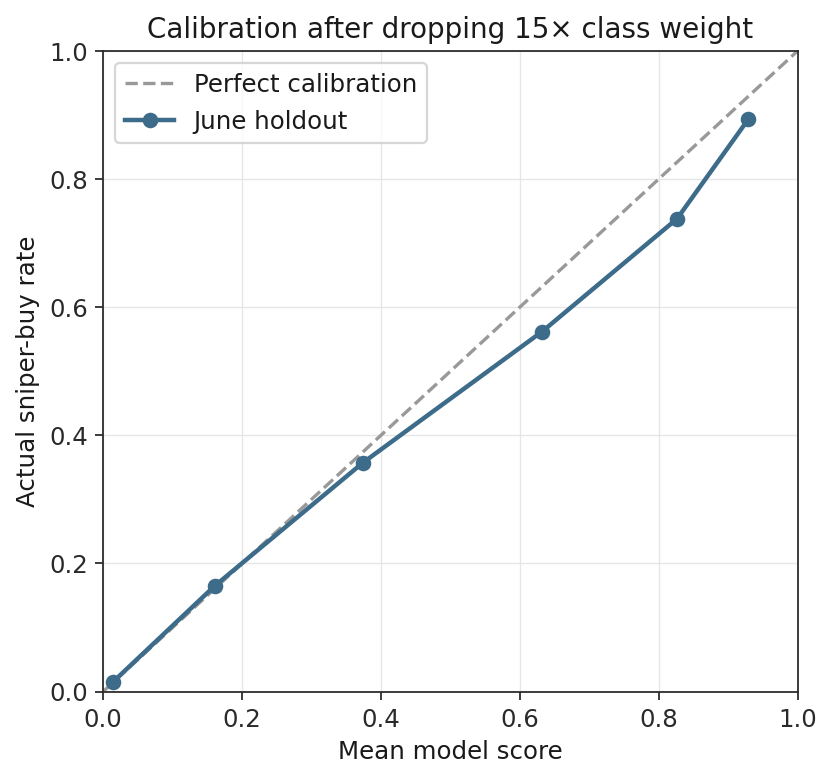

*Figure 9 — After dropping 15× class weight, high scores (~0.9) match ~89% true snipes in-sample.*

In [6]:
show("04_ablation.png",
     "Figure 7 — Each block of features adds ranking power; all three together win.")
show("08_roc.png",
     "Figure 8 — ROC on the June holdout sample (AUC 0.95).")
show("10_calibration.png",
     "Figure 9 — After dropping 15× class weight, high scores (~0.9) match ~89% true snipes in-sample.")


## Part 3 — Replica vs the bot (rubric ~35 pts)


Same June sample, threshold **frozen** from valid:

| | Bot | Replica |
|---|---|---|
| Buys | 2,445 | 3,564 |
| Overlap | — | **1,989 (81% recall)** |
| Precision | — | 56% |
| Net SOL on tokens with a wallet path | **+1,192** | **+970** (overlap only) |

1,575 extra replica buys have **no local price** (`mcap_candles` ~2.8 GiB not used). That P&L is not invented.

A public replica that fills **+1 slot** late loses ~5 SOL. Matching *who* is not matching *the fill*.


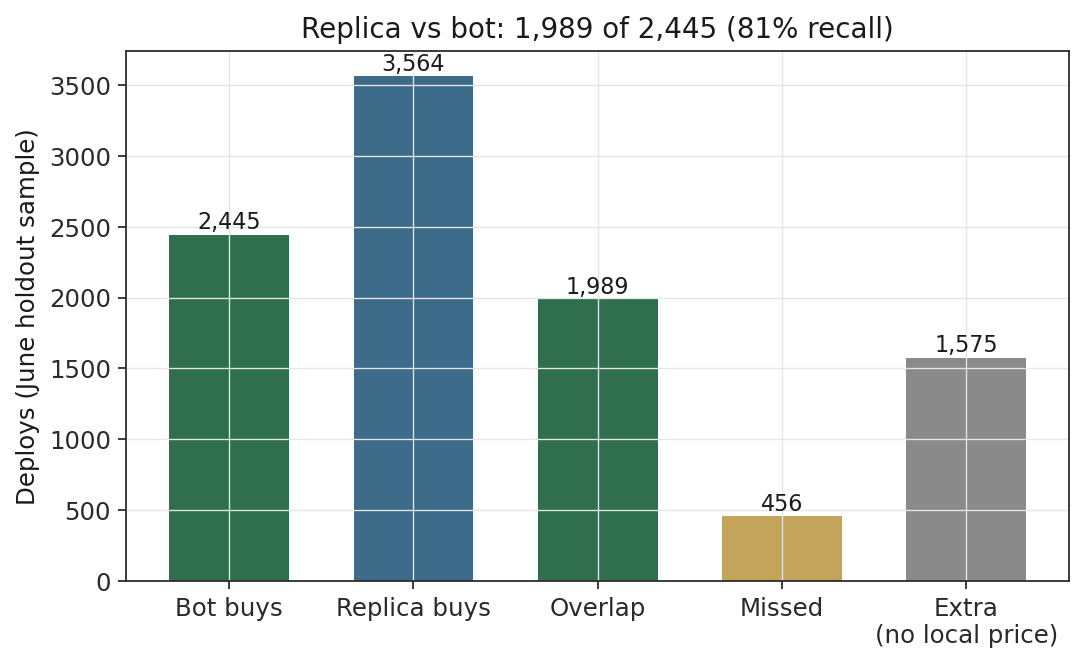

*Figure 10 — 1,989 of 2,445 bot buys recovered (81%). Extra replica buys are unlabeled on price.*

In [7]:
show("07_replica.png",
     "Figure 10 — 1,989 of 2,445 bot buys recovered (81%). Extra replica buys are unlabeled on price.")


## Reproducibility (rubric ~10 pts)

| Piece | Where |
|---|---|
| This story + figures | this notebook |
| Full pipeline | GitHub: `scripts/`, `src/` |
| Metrics dump | `data/metadata/kaggle_train_backtest.json` |
| Raw challenge files | competition hosts (wallet + TAR). Not republished here (~30 GB). |

Local rerun (needs the challenge files on disk):

```bash
python scripts/train_eval.py
python scripts/make_figures.py
```

`t_decision` rule: deployment `blockTime` only. Post-deploy data is P&L, never a feature.


## What we would not claim

The sniper is not an oracle. He is a **same-block hunter** with a **trust list** and a **factory filter**. That reconstructs most of his buys and explains the +8.9k SOL book. Landing in the same slot is a separate systems problem.
